In [2]:
import matplotlib.pyplot as plt
import numpy as np

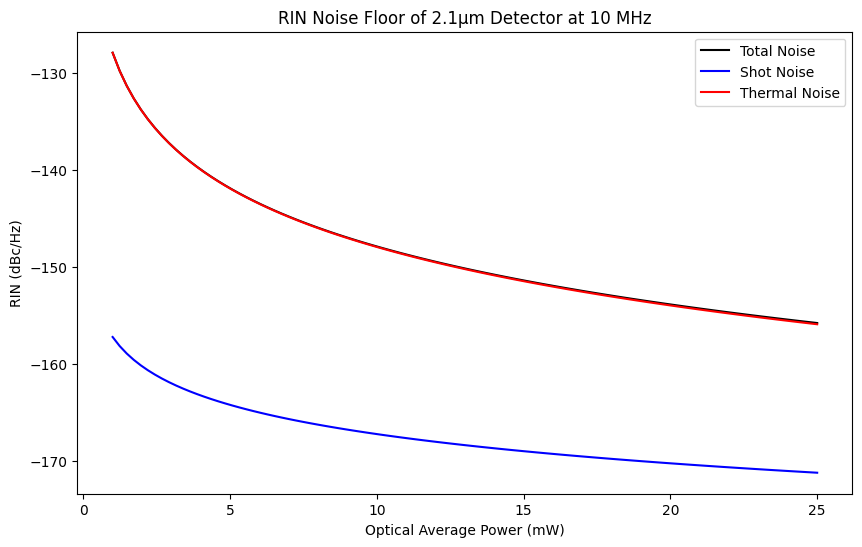

In [3]:
R_load = 50  # Load resistance in ohms

S_v_thermal = (400e-9)**2  # Thermal, dark, TIA noise voltage spectral density in V^2/Hz

responsivity = 1e3 # V/W, voltage responsivity of the photodetector

wavelength = 2.1e-6  # Wavelength in meters
h = 6.626e-34  # Planck's constant in J*s
frequency = 3e8 / wavelength  # Frequency in Hz
photon_energy = h * frequency  # Photon energy in J

optical_power = np.linspace(1e-3, 2.5e-2, 101)  # Optical average power range from 1mW to 100 mW

S_I_shot = 2 * photon_energy * optical_power  # Shot noise current spectral density in optical power W^2/Hz




N_shot = S_I_shot * (responsivity**2)/R_load  # Shot noise electrical power PSD in W/Hz

N_thermal = S_v_thermal / R_load  # Thermal noise electrical power PSD in W/Hz

N_total = N_shot + N_thermal  # Total noise electrical power PSD in W/Hz

avg_elec_power = (optical_power * responsivity)**2/R_load  # Average electrical power in W


RIN_shot = 10 * np.log10(N_shot / avg_elec_power)  # RIN in dB/Hz
RIN_thermal = 10 * np.log10(N_thermal / avg_elec_power)  # RIN in dB/Hz

RIN = 10 * np.log10(N_total / avg_elec_power)  # RIN in dB/Hz

plt.figure(figsize=(10, 6))
plt.plot(optical_power*1e3, RIN, label='Total Noise', color='black')
plt.plot(optical_power*1e3, RIN_shot, label='Shot Noise', color='blue')
plt.plot(optical_power*1e3, RIN_thermal, label='Thermal Noise', color='red')
plt.xlabel('Optical Average Power (mW)')
plt.ylabel('RIN (dBc/Hz)')
# plt.xscale('log')
plt.title('RIN Noise Floor of 2.1µm Detector at 10 MHz')
plt.legend()

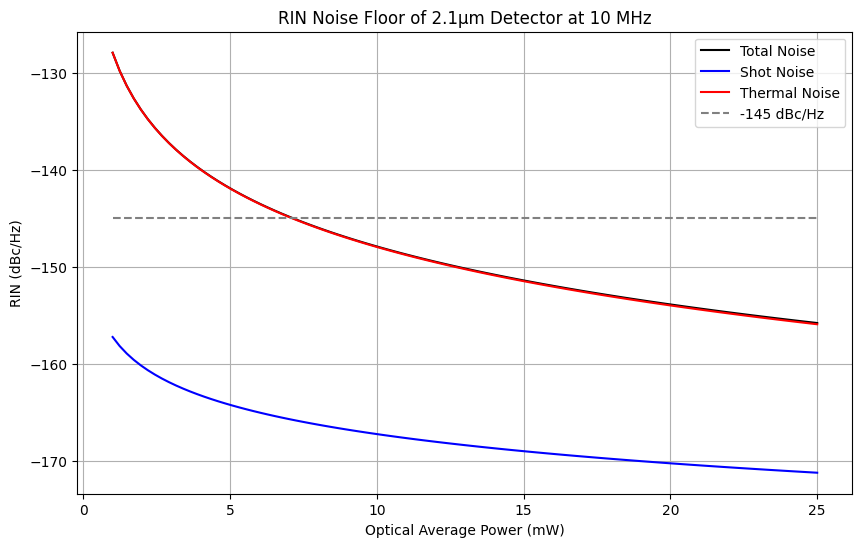

In [4]:
S_V_shot = S_I_shot * responsivity**2  # Shot noise voltage PSD in V^2/Hz

avg_voltage = optical_power * responsivity  # Average voltage in V

S_V_total = S_V_shot + S_v_thermal  # Total voltage noise PSD in V^2/Hz

RIN_V_shot = 10 * np.log10(S_V_shot / (avg_voltage**2))  # RIN in dB/Hz
RIN_V_thermal = 10 * np.log10(S_v_thermal / (avg_voltage**2))  # RIN in dB/Hz

RIN_V = 10 * np.log10(S_V_total / (avg_voltage**2))  # RIN in dB/Hz

plt.figure(figsize=(10, 6))
plt.plot(optical_power*1e3, RIN_V, label='Total Noise', color='black')
plt.plot(optical_power*1e3, RIN_V_shot, label='Shot Noise', color='blue')
plt.plot(optical_power*1e3, RIN_V_thermal, label='Thermal Noise', color='red')
# plt.plot(optical_power*1e3, RIN, label='Total Noise (Electrical Power)', color='green', linestyle='--')
plt.xlabel('Optical Average Power (mW)')
plt.ylabel('RIN (dBc/Hz)')
# plt.xscale('log')
plt.title('RIN Noise Floor of 2.1µm Detector at 10 MHz')
plt.grid()
plt.hlines(-145,optical_power[0]*1e3, optical_power[-1]*1e3, colors='gray', linestyles='dashed', label='-145 dBc/Hz')
plt.legend()
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_2.1um_detector_10MHz.svg")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_2.1um_detector_10MHz.pdf")

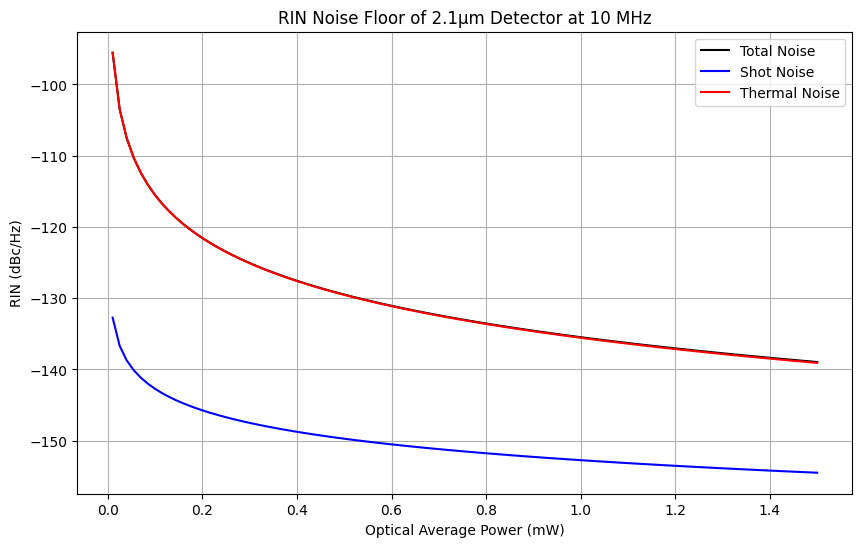

In [ ]:
#Koheron detector:

R_load = 50  # Load resistance in ohms

e = 1.602e-19  # Elementary charge in C

current_responsivity = 0.6 # A/W, half of peak responsivity of the photodetector (since we are at the edge of the responsivity curve)

ti_gain = 5e3 # V/A, transimpedance gain of the photodetector

responsivity = current_responsivity*ti_gain  # V/W, voltage responsivity of the photodetector

# NEP = 5e-12  # Noise Equivalent Power in W/Hz^0.5, estimate for the detector at 10 MHz, 2pW/Hz^0.5 at 1MHz, we check 10MHz (optical power pr sqrt(Hz))

# S_v_thermal = (NEP * responsivity)**2  # Thermal, dark, TIA noise voltage spectral density in V^2/Hz

# N_v_thermal = S_v_thermal/R_load  # Thermal, dark, TIA noise power PSD in W/Hz, estimate, 2pW at 1MHz, we check 10MHz

N_v_thermal = 10**(-143/10) # Thermal, dark, TIA noise power PSD in W/Hz, estimate, 2pW at 1MHz, we check 10MHz

S_v_thermal = N_v_thermal*R_load






wavelength = 2.1e-6  # Wavelength in meters
h = 6.626e-34  # Planck's constant in J*s
frequency = 3e8 / wavelength  # Frequency in Hz
photon_energy = h * frequency  # Photon energy in J

optical_power = np.linspace(1e-5, 1.5e-3, 101)  # Optical average power range from 10µW to 1.5 mW

S_I_shot = 2 * photon_energy * optical_power  # Shot noise current spectral density in optical power W^2/Hz

S_i_shot = 2 * e*current_responsivity * optical_power  # Shot noise current spectral density in A^2/Hz

S_V_shot_alt = S_I_shot * responsivity**2   # Shot noise voltage PSD in V^2/Hz
S_V_shot = S_i_shot * ti_gain**2  # Shot noise voltage PSD in V^2/Hz, alternative calculation using current


avg_voltage = optical_power * responsivity  # Average voltage in V

S_V_total = S_V_shot + S_v_thermal  # Total voltage noise PSD in V^2/Hz

N_shot = S_V_shot/R_load  # Shot noise electrical power PSD in W/Hz

N_thermal = S_v_thermal / R_load  # Thermal noise electrical power PSD in W/Hz

N_total = N_shot + N_thermal  # Total noise electrical power PSD in W/Hz

avg_elec_power = (optical_power * responsivity)**2/R_load  # Average electrical power in W


RIN_shot = 10 * np.log10(N_shot / avg_elec_power)  # RIN in dB/Hz
RIN_thermal = 10 * np.log10(N_thermal / avg_elec_power)  # RIN in dB/Hz

RIN = 10 * np.log10(N_total / avg_elec_power)  # RIN in dB/Hz

plt.figure(figsize=(10, 6))
plt.plot(optical_power*1e3, RIN, label='Total Noise', color='black')
plt.plot(optical_power*1e3, RIN_shot, label='Shot Noise', color='blue')
plt.plot(optical_power*1e3, RIN_thermal, label='Thermal Noise', color='red')
plt.xlabel('Optical Average Power (mW)')
plt.ylabel('RIN (dBc/Hz)')
# plt.xscale('log')
plt.title('RIN Noise Floor of 2.1µm Detector at 10 MHz')
plt.legend()
plt.grid()

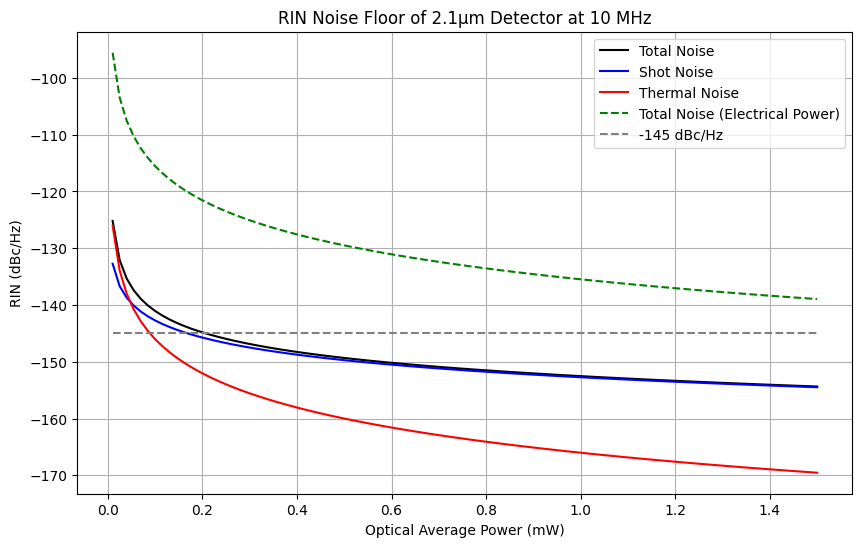

In [6]:
#Koheron detector:

R_load = 50  # Load resistance in ohms



e = 1.602e-19  # Elementary charge in C

current_responsivity = 0.6 # A/W, half of peak responsivity of the photodetector (since we are at the edge of the responsivity curve)

ti_gain = 5e3 # V/A, transimpedance gain of the photodetector

responsivity = current_responsivity*ti_gain  # V/W, voltage responsivity of the photodetector

NEP = 5e-12  # Noise Equivalent Power in W/Hz^0.5, estimate for the detector at 10 MHz, 2pW/Hz^0.5 at 1MHz, we check 10MHz (optical power pr sqrt(Hz))

S_v_thermal = (NEP * responsivity)**2  # Thermal, dark, TIA noise voltage spectral density in V^2/Hz

N_v_thermal = S_v_thermal/R_load  # Thermal, dark, TIA noise power PSD in W/Hz, estimate, 2pW at 1MHz, we check 10MHz


wavelength = 2.1e-6  # Wavelength in meters
h = 6.626e-34  # Planck's constant in J*s
frequency = 3e8 / wavelength  # Frequency in Hz
photon_energy = h * frequency  # Photon energy in J

optical_power = np.linspace(1e-5, 1.5e-3, 101)  # Optical average power range from 10µW to 1.5 mW

S_I_shot = 2 * photon_energy * optical_power  # Shot noise current spectral density in optical power W^2/Hz

S_i_shot = 2 * e*current_responsivity * optical_power  # Shot noise current spectral density in A^2/Hz

S_V_shot_alt = S_I_shot * responsivity**2   # Shot noise voltage PSD in V^2/Hz
S_V_shot = S_i_shot * ti_gain**2  # Shot noise voltage PSD in V^2/Hz, alternative calculation using current


avg_voltage = optical_power * responsivity  # Average voltage in V

S_V_total = S_V_shot + S_v_thermal  # Total voltage noise PSD in V^2/Hz


RIN_V_shot = 10 * np.log10(S_V_shot / (avg_voltage**2))  # RIN in dB/Hz
RIN_V_thermal = 10 * np.log10(S_v_thermal / (avg_voltage**2))  # RIN in dB/Hz

RIN_V = 10 * np.log10(S_V_total / (avg_voltage**2))  # RIN in dB/Hz

plt.figure(figsize=(10, 6))
plt.plot(optical_power*1e3, RIN_V, label='Total Noise', color='black')
plt.plot(optical_power*1e3, RIN_V_shot, label='Shot Noise', color='blue')
plt.plot(optical_power*1e3, RIN_V_thermal, label='Thermal Noise', color='red')
plt.plot(optical_power*1e3, RIN, label='Total Noise (Electrical Power)', color='green', linestyle='--')
plt.xlabel('Optical Average Power (mW)')
plt.ylabel('RIN (dBc/Hz)')
# plt.xscale('log')
plt.title('RIN Noise Floor of 2.1µm Detector at 10 MHz')
plt.grid()
plt.hlines(-145,optical_power[0]*1e3, optical_power[-1]*1e3, colors='gray', linestyles='dashed', label='-145 dBc/Hz')
plt.legend()

In [7]:
10*np.log10(N_v_thermal)

-173.46787486224656